In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import datetime as dt

In [2]:
df = pd.read_csv("data/real_dataset/Motor_vehicle_insurance_data.csv", sep=";")

In [3]:
# df.describe()
df.dtypes

ID                        int64
Date_start_contract      object
Date_last_renewal        object
Date_next_renewal        object
Date_birth               object
Date_driving_licence     object
Distribution_channel      int64
Seniority                 int64
Policies_in_force         int64
Max_policies              int64
Max_products              int64
Lapse                     int64
Date_lapse               object
Payment                   int64
Premium                 float64
Cost_claims_year        float64
N_claims_year             int64
N_claims_history          int64
R_Claims_history        float64
Type_risk                 int64
Area                      int64
Second_driver             int64
Year_matriculation        int64
Power                     int64
Cylinder_capacity         int64
Value_vehicle           float64
N_doors                   int64
Type_fuel                object
Length                  float64
Weight                    int64
dtype: object

In [4]:
df.columns

Index(['ID', 'Date_start_contract', 'Date_last_renewal', 'Date_next_renewal',
       'Date_birth', 'Date_driving_licence', 'Distribution_channel',
       'Seniority', 'Policies_in_force', 'Max_policies', 'Max_products',
       'Lapse', 'Date_lapse', 'Payment', 'Premium', 'Cost_claims_year',
       'N_claims_year', 'N_claims_history', 'R_Claims_history', 'Type_risk',
       'Area', 'Second_driver', 'Year_matriculation', 'Power',
       'Cylinder_capacity', 'Value_vehicle', 'N_doors', 'Type_fuel', 'Length',
       'Weight'],
      dtype='object')

In [5]:
df.head()

,ID,Date_start_contract,Date_last_renewal,Date_next_renewal,Date_birth,Date_driving_licence,Distribution_channel,Seniority,Policies_in_force,Max_policies,...,Area,Second_driver,Year_matriculation,Power,Cylinder_capacity,Value_vehicle,N_doors,Type_fuel,Length,Weight
0,1,05/11/2015,05/11/2015,05/11/2016,15/04/1956,20/03/1976,0,4,1,2,...,0,0,2004,80,599,7068.0,0,P,NaN,190
1,1,05/11/2015,05/11/2016,05/11/2017,15/04/1956,20/03/1976,0,4,1,2,...,0,0,2004,80,599,7068.0,0,P,NaN,190
2,1,05/11/2015,05/11/2017,05/11/2018,15/04/1956,20/03/1976,0,4,2,2,...,0,0,2004,80,599,7068.0,0,P,NaN,190
3,1,05/11/2015,05/11/2018,05/11/2019,15/04/1956,20/03/1976,0,4,2,2,...,0,0,2004,80,599,7068.0,0,P,NaN,190
4,2,26/09/2017,26/09/2017,26/09/2018,15/04/1956,20/03/1976,0,4,2,2,...,0,0,2004,80,599,7068.0,0,P,NaN,190


In [6]:
# Reformatting date variables to determine driver age and numere of years driving  
df['Date_birth'] = pd.to_datetime(df['Date_birth'], format='%d/%m/%Y')
df['Date_driving_licence'] = pd.to_datetime(df['Date_driving_licence'], format='%d/%m/%Y')

In [7]:
df.head()

,ID,Date_start_contract,Date_last_renewal,Date_next_renewal,Date_birth,Date_driving_licence,Distribution_channel,Seniority,Policies_in_force,Max_policies,...,Area,Second_driver,Year_matriculation,Power,Cylinder_capacity,Value_vehicle,N_doors,Type_fuel,Length,Weight
0,1,05/11/2015,05/11/2015,05/11/2016,1956-04-15,1976-03-20,0,4,1,2,...,0,0,2004,80,599,7068.0,0,P,NaN,190
1,1,05/11/2015,05/11/2016,05/11/2017,1956-04-15,1976-03-20,0,4,1,2,...,0,0,2004,80,599,7068.0,0,P,NaN,190
2,1,05/11/2015,05/11/2017,05/11/2018,1956-04-15,1976-03-20,0,4,2,2,...,0,0,2004,80,599,7068.0,0,P,NaN,190
3,1,05/11/2015,05/11/2018,05/11/2019,1956-04-15,1976-03-20,0,4,2,2,...,0,0,2004,80,599,7068.0,0,P,NaN,190
4,2,26/09/2017,26/09/2017,26/09/2018,1956-04-15,1976-03-20,0,4,2,2,...,0,0,2004,80,599,7068.0,0,P,NaN,190


In [8]:
# Calculate driver Age and years licensed

today = dt.date.today()
df['age'] = df['Date_birth'].apply(
    lambda born: today.year - born.year - ((today.month, today.day) < (born.month, born.day))
)
today = dt.date.today()
df['years_driving'] = df['Date_driving_licence'].apply(
    lambda born: today.year - born.year - ((today.month, today.day) < (born.month, born.day))
)

In [9]:
# df["N_claims_year"].value_counts()

In [10]:
df = df[['ID','Date_birth', 'Date_driving_licence', 'age', 'years_driving', 'Distribution_channel',
        'Seniority','Premium', 'Cost_claims_year',
        'N_claims_year', 'N_claims_history', 'R_Claims_history',
        "Power",
        "Cylinder_capacity",
        "Value_vehicle",
        "Area"]]
# df = df[df["N_claims_year"]]

In [11]:
df = df.sample(1000)
df

,ID,Date_birth,Date_driving_licence,age,years_driving,Distribution_channel,Seniority,Premium,Cost_claims_year,N_claims_year,N_claims_history,R_Claims_history,Power,Cylinder_capacity,Value_vehicle,Area
92124,46129,1969-02-04,1993-03-01,56,32,0,6,229.08,0.0,0,2,0.00,75,1896,18270.00,0
40035,19380,1959-10-29,1989-02-09,65,36,0,2,752.60,0.0,0,2,0.00,143,2498,35758.04,0
18289,8996,1983-01-27,2003-05-12,42,22,0,5,564.33,0.0,0,2,0.79,115,1197,19900.00,0
85968,43050,1963-06-01,1992-01-28,62,33,0,5,341.27,2411.2,2,2,1.56,90,1197,16274.68,0
66145,32898,1982-03-19,2005-03-10,43,20,0,4,316.17,0.0,0,3,0.00,64,2178,29155.00,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14610,7241,1983-10-11,2005-07-05,41,20,0,6,225.66,0.0,0,2,0.00,90,1560,18473.10,0
47570,23299,1959-11-08,1978-01-25,65,47,0,10,311.79,0.0,0,5,0.55,90,1560,17590.00,0
72985,36545,1965-09-09,1984-02-20,60,41,0,11,131.41,0.0,0,1,0.00,0,49,2460.00,0
40872,19797,1965-04-21,1983-06-15,60,42,0,8,341.21,0.0,0,0,0.00,75,1360,13350.00,0


In [68]:
import pandas as pd
import numpy as np

np.random.seed(42)
expanded_rows = []

for _, row in df.iterrows():
    # get claim frequency for this driver-year
    n_claims = row["N_claims_year"]

    # probabilistic monthly claim assignment
    # monthly probability = n_claims / 12
    # monthly_claims = np.random.binomial(1, n_claims / 12, size=12)
    if n_claims > 12:
        n_claims = 12
    claim_months = np.random.choice(12, n_claims, replace=False)
    monthly_claims = [1 if m in claim_months else 0 for m in range(12)]


    for month in range(1, 13):
        new_row = row.copy()
        new_row["Month"] = month
        new_row["Claim_this_month"] = monthly_claims[month - 1]

        if monthly_claims[month - 1] == 1:
            # Claims will be correlated to bad driving, high average speed
            # hard brakes, and acceleration, and high speeding events.
            
            # Averate speed of trip is normally distributed, neigborhood driving at 10 mph over limit, 40mph
            new_row["avg_speed"] = np.random.normal(40, 10, size=1)[0]   # mph
            new_row["hard_brakes"] = np.random.poisson(2, size=1)[0]     # counts
            new_row["hard_accel"] = np.random.poisson(2, size=1)[0]     # counts
            new_row["speeding_events"] = np.random.poisson(2, size=1)[0] # counts
            # Average commute time is 20 mins
            new_row["trip_len"] = np.random.normal(35, 10, size=1)[0] # counts

        else:
            # Averate speed of trip is normally distributed, neigborhood driving at 30mph
            new_row["avg_speed"] = np.random.normal(25, 10, size=1)[0]   # mph
            
            new_row["hard_brakes"] = np.random.poisson(1, size=1)[0]     # counts
            new_row["hard_accel"] = np.random.poisson(1, size=1)[0]     # counts
            new_row["speeding_events"] = np.random.poisson(1, size=1)[0] # counts
            # Average commute time is 20 mins
            new_row["trip_len"] = np.random.normal(20, 10, size=1)[0] # counts

        expanded_rows.append(new_row)

monthly_df = pd.DataFrame(expanded_rows)



In [69]:
df

,ID,Date_birth,Date_driving_licence,age,years_driving,Distribution_channel,Seniority,Premium,Cost_claims_year,N_claims_year,N_claims_history,R_Claims_history,Power,Cylinder_capacity,Value_vehicle,Area
92124,46129,1969-02-04,1993-03-01,56,32,0,6,229.08,0.0,0,2,0.00,75,1896,18270.00,0
40035,19380,1959-10-29,1989-02-09,65,36,0,2,752.60,0.0,0,2,0.00,143,2498,35758.04,0
18289,8996,1983-01-27,2003-05-12,42,22,0,5,564.33,0.0,0,2,0.79,115,1197,19900.00,0
85968,43050,1963-06-01,1992-01-28,62,33,0,5,341.27,2411.2,2,2,1.56,90,1197,16274.68,0
66145,32898,1982-03-19,2005-03-10,43,20,0,4,316.17,0.0,0,3,0.00,64,2178,29155.00,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14610,7241,1983-10-11,2005-07-05,41,20,0,6,225.66,0.0,0,2,0.00,90,1560,18473.10,0
47570,23299,1959-11-08,1978-01-25,65,47,0,10,311.79,0.0,0,5,0.55,90,1560,17590.00,0
72985,36545,1965-09-09,1984-02-20,60,41,0,11,131.41,0.0,0,1,0.00,0,49,2460.00,0
40872,19797,1965-04-21,1983-06-15,60,42,0,8,341.21,0.0,0,0,0.00,75,1360,13350.00,0


In [70]:
monthly_df

,ID,Date_birth,Date_driving_licence,age,years_driving,Distribution_channel,Seniority,Premium,Cost_claims_year,N_claims_year,...,Cylinder_capacity,Value_vehicle,Area,Month,Claim_this_month,avg_speed,hard_brakes,hard_accel,speeding_events,trip_len
92124,46129,1969-02-04,1993-03-01,56,32,0,6,229.08,0.0,0,...,1896,18270.0,0,1,0,28.925798,0,2,3,10.708153
92124,46129,1969-02-04,1993-03-01,56,32,0,6,229.08,0.0,0,...,1896,18270.0,0,2,0,25.222218,1,1,0,15.722071
92124,46129,1969-02-04,1993-03-01,56,32,0,6,229.08,0.0,0,...,1896,18270.0,0,3,0,10.236703,3,1,2,34.869810
92124,46129,1969-02-04,1993-03-01,56,32,0,6,229.08,0.0,0,...,1896,18270.0,0,4,0,32.791926,2,1,1,8.989022
92124,46129,1969-02-04,1993-03-01,56,32,0,6,229.08,0.0,0,...,1896,18270.0,0,5,0,28.229998,0,2,2,6.065831
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
85329,42733,1984-11-30,2003-11-19,40,21,0,7,448.37,0.0,0,...,1461,19450.0,1,8,0,23.513194,2,1,0,15.821923
85329,42733,1984-11-30,2003-11-19,40,21,0,7,448.37,0.0,0,...,1461,19450.0,1,9,0,4.430175,2,1,2,28.502693
85329,42733,1984-11-30,2003-11-19,40,21,0,7,448.37,0.0,0,...,1461,19450.0,1,10,0,8.203032,1,1,1,37.028563
85329,42733,1984-11-30,2003-11-19,40,21,0,7,448.37,0.0,0,...,1461,19450.0,1,11,0,5.691007,1,0,2,20.891063


In [61]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, classification_report
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline


# Target variable: monthly claims (binary)
y = monthly_df["Claim_this_month"]

# Features: pick a subset for now
feature_cols = [
    "age",
    "years_driving",
    
    "avg_speed",
    "hard_accel",
    "hard_brakes",
    "trip_len",
    "speeding_events",
    
    'N_claims_history', 
    'R_Claims_history',
    "Power",
    "Seniority",
    "Cylinder_capacity",
    "Value_vehicle",
    "Area"
]

X = monthly_df[feature_cols]

# ----------------------------
# Step 2: Train-test split
# ----------------------------
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

# ----------------------------
# Step 3: Fit logistic regression
# ----------------------------


pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("logreg", LogisticRegression(max_iter=1000, class_weight="balanced"))
])

pipeline.fit(X_train, y_train)
y_pred_proba = pipeline.predict_proba(X_test)[:, 1]



In [62]:
y_train.value_counts()

Claim_this_month
0    8143
1     257
Name: count, dtype: int64

In [63]:
y_test.value_counts()

Claim_this_month
0    3490
1     110
Name: count, dtype: int64

In [64]:

# ----------------------------
# Step 4: Evaluate
# ----------------------------
y_pred_proba = pipeline.predict_proba(X_test)[:, 1]  # risk score = probability of claim
auc = roc_auc_score(y_test, y_pred_proba)
print("ROC-AUC:", auc)
print(classification_report(y_test, (y_pred_proba > 0.5).astype(int)))

# ----------------------------
# Step 5: Attach risk scores back to dataset
# ----------------------------
monthly_df["risk_factor"] = pipeline.predict_proba(X)[:, 1]

# Example: premium calculation
base_premium = 300
alpha = 1000
monthly_df["premium"] = base_premium + alpha * monthly_df["risk_factor"]

print(monthly_df[["Month", "risk_factor", "premium"]].head(12))


ROC-AUC: 0.9328028132326127
              precision    recall  f1-score   support

           0       0.99      0.87      0.93      3490
           1       0.17      0.85      0.29       110

    accuracy                           0.87      3600
   macro avg       0.58      0.86      0.61      3600
weighted avg       0.97      0.87      0.91      3600

       Month  risk_factor     premium
92124      1     0.217227  517.227437
92124      2     0.030730  330.730491
92124      3     0.410845  710.845078
92124      4     0.111452  411.451837
92124      5     0.118621  418.621035
92124      6     0.208661  508.660881
92124      7     0.016581  316.580799
92124      8     0.111188  411.187610
92124      9     0.333840  633.840254
92124     10     0.129896  429.896292
92124     11     0.113728  413.728383
92124     12     0.031670  331.669596


In [65]:
monthly_df[[    "avg_speed",
    "hard_brakes",
    "speeding_events",
    'N_claims_history', 
    'R_Claims_history',
    "Power",
    "Seniority",
    "Cylinder_capacity",
    "Value_vehicle",
    "Area","risk_factor","premium"]].sample(10).sort_values(by='risk_factor', ascending=False)

,avg_speed,hard_brakes,speeding_events,N_claims_history,R_Claims_history,Power,Seniority,Cylinder_capacity,Value_vehicle,Area,risk_factor,premium
83301,25.823057,1,3,10,2.00,150,12,1896,22265.00,0,0.957075,1257.074635
52461,29.598420,0,1,10,2.33,71,4,1905,13162.17,0,0.770805,1070.804865
77255,29.958912,1,1,6,0.00,90,4,1560,21700.00,1,0.247897,547.896961
74861,8.929879,1,1,3,0.23,90,8,1590,7662.90,0,0.159597,459.597161
98946,29.874058,0,1,2,0.34,115,6,2171,23982.79,0,0.112878,412.877563
80375,20.404833,1,1,1,0.50,150,3,1587,23210.00,0,0.100222,400.221502
102954,38.517722,2,0,1,0.36,12,3,125,2899.00,1,0.069591,369.591027
13340,29.474458,1,2,0,0.00,163,2,1769,12068.32,0,0.069264,369.264189
95491,18.917115,0,0,3,0.00,120,11,599,9321.10,0,0.009742,309.741886
44501,19.664056,0,1,0,0.00,15,3,125,3099.00,0,0.009473,309.472990


In [66]:
coefficients = pipeline['logreg'].coef_[0] # Assuming binary classification, take the first row
feature_names = X_train.columns
feature_importance = pd.DataFrame({'Feature': feature_names, 'Importance': coefficients})
feature_importance = feature_importance.sort_values(by='Importance', ascending=False)

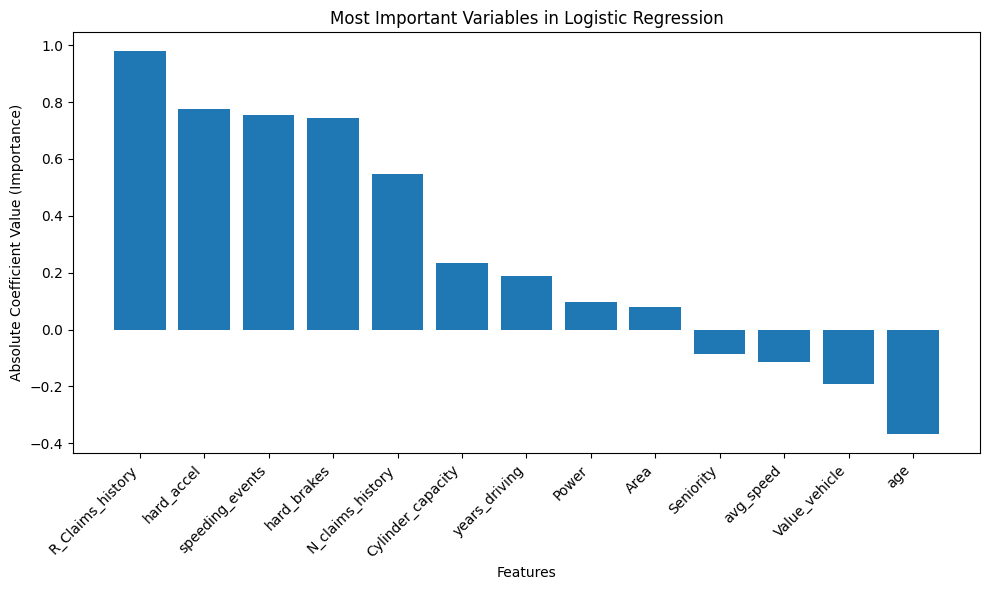

In [67]:
plt.figure(figsize=(10, 6))
plt.bar(feature_importance['Feature'], feature_importance['Importance'])
plt.xlabel('Features')
plt.ylabel('Absolute Coefficient Value (Importance)')
plt.title('Most Important Variables in Logistic Regression')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

<Axes: xlabel='risk_factor', ylabel='hard_accel'>

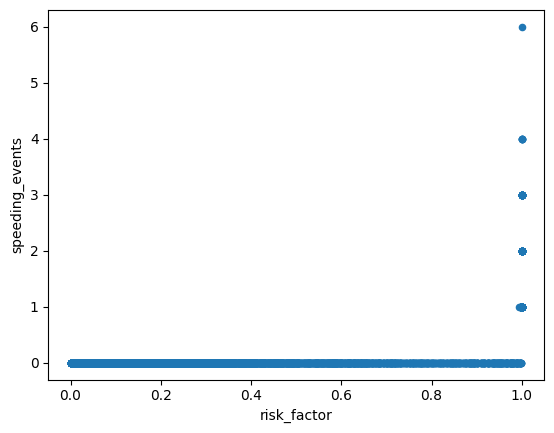

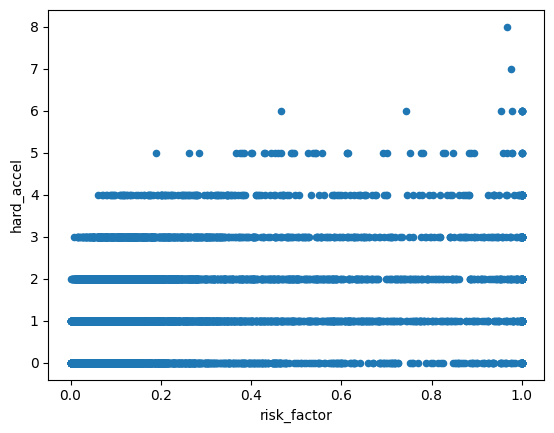

In [33]:
monthly_df.plot(kind="scatter",x="risk_factor", y="speeding_events")
monthly_df.plot(kind="scatter",x="risk_factor", y="hard_accel")

AttributeError: 'Axes' object has no attribute 'value_counts'

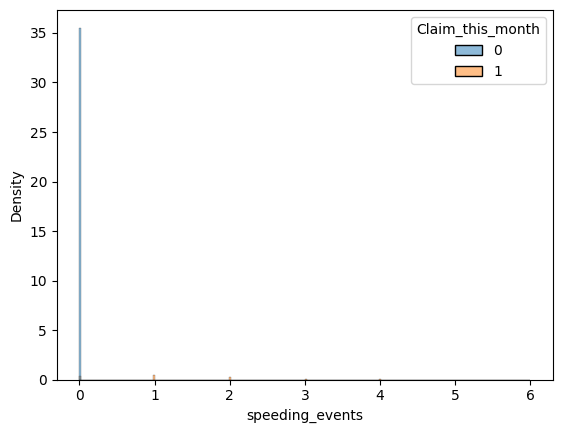

In [45]:
sns.histplot(data=monthly_df, x="speeding_events", hue="Claim_this_month",stat='density').value_counts()

In [47]:
monthly_df[monthly_df["Claim_this_month"]==0]["speeding_events"].value_counts()

speeding_events
0    11633
Name: count, dtype: int64

In [48]:
monthly_df[monthly_df["Claim_this_month"]==1]["speeding_events"].value_counts()

speeding_events
1    142
0    121
2     70
3     28
4      5
6      1
Name: count, dtype: int64